### Architecture 
In this experiment, feature concat based fusion is applied by using the EfficientNetB1 backbone to extract image embeddings. A big MLP with higher depth and width is used to embed the tabular features, and both embeddings are concatenated. A final MLP head is then applied, and the model is trained and fine‑tuned using this combination. Light augmentation is added to the images with simple horizontal flipping. In each fold, the model is trained on 4 folds and validated on the remaining fold. After all folds, out‑of‑fold predictions are stored, and RMSE is calculated on these OOF predictions to generalize the overall performance.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [3]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config
from src.data import build_transforms, ImageTabDataset
from src.models import FeatureConcatFusionNet



main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs", "extra", "exp4_EffB1_simple_FeatureConcatFusion_BS12")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp4"]   # define in config
cfg["name"] = "exp4_EffB1_simple_FeatureConcatFusion_BS12"
cfg["batch_size"] = 12
cfg["img_size"]= 384
cfg["aug"]="strong"
TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="fusion",      
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    tab_encoder_capacity="big", # "small" is 2-layer MLP, "big" is deeper and wider 5-layer MLP
    
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp4_EffB1_simple_FeatureConcatFusion_BS12: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=31.0710 | ValRMSE: 19.7756
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=18.9372 | ValRMSE: 18.9563
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=18.2402 | ValRMSE: 18.6570
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=17.5671 | ValRMSE: 19.6009
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=16.9769 | ValRMSE: 19.1703
Epoch 6/10 | Fold 1 | Train[MSE]: RMSE=16.0287 | ValRMSE: 19.8278
Epoch 7/10 | Fold 1 | Train[MSE]: RMSE=15.4842 | ValRMSE: 2464206.0000
Epoch 8/10 | Fold 1 | Train[MSE]: RMSE=15.1347 | ValRMSE: 20.1504
Early stopping at epoch 8
Fold 1 best RMSE: 18.6570

=== exp4_EffB1_simple_FeatureConcatFusion_BS12: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[MSE]: RMSE=32.0950 | ValRMSE: 19.8781
Epoch 2/10 | Fold 2 | Train[MSE]: RMSE=18.8713 | ValRMSE: 18.7487
Epoch 3/10 | Fold 2 | Train[MSE]: RMSE=18.2266 | ValRMSE: 19.4105
Epoch 4/10 | Fold 2 | Train[MSE]: RMSE=17.5127 | ValRMSE: 19.6914
Epoch 5/10 | Fold 2 | Train[MSE

In [5]:
import pandas
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 18.6570 (n=1983)
Fold 2 OOF RMSE: 18.7487 (n=1983)
Fold 3 OOF RMSE: 18.2444 (n=1982)
Fold 4 OOF RMSE: 18.6730 (n=1982)
Fold 5 OOF RMSE: 18.9636 (n=1982)


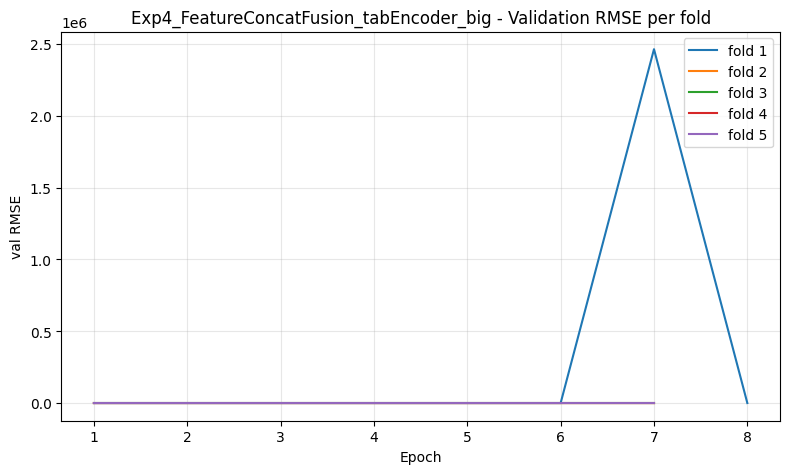

In [6]:
from src.plot import plot_all_folds_history
plot_all_folds_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp4_FeatureConcatFusion_tabEncoder_big")

In [7]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,4c1e05895368c997fdd709bbd1ac3dae,2,2,103.379494,101.379494
1,76769dbee1699e04ae1befa3128db7d6,2,100,18.359705,81.640295
2,d00e5d29d4ec09de1e0e0ebec41b2d03,1,5,81.491005,76.491005
3,ec07599018885a44734a9ba27d306055,2,99,23.272617,75.727383
4,e5a84da44afc0abddfbb36907a5ee845,5,100,24.566288,75.433712


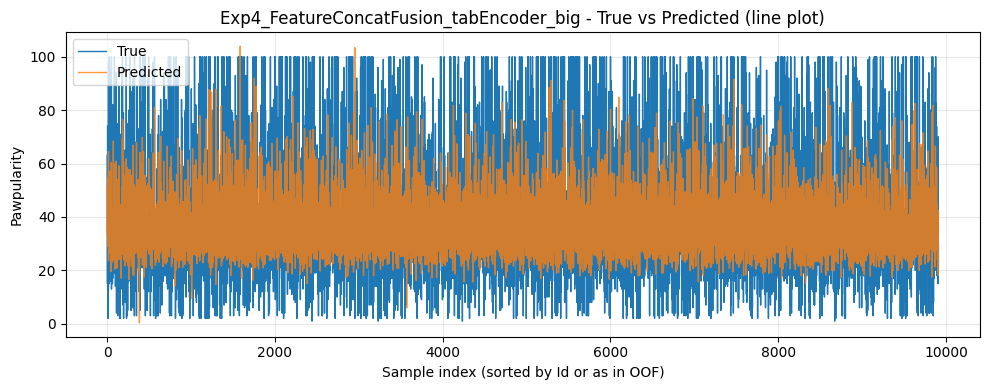

In [8]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="Exp4_FeatureConcatFusion_tabEncoder_big")





In [9]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a="../outputs/exp2/oof_detail.csv",
    oof_path_b="../outputs/exp4/oof_detail.csv",
    bins=bins,
    label_a="Exp2_Eff_NoFusion",
    label_b="Exp4_Eff_EarlyFusion",
    title_prefix="EfficientNet",
)

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/exp2/oof_detail.csv'

In [ ]:
df_bins.head()

,bin,count,Exp2_Eff_NoFusion_rmse,Exp4_Eff_EarlyFusion_rmse,rmse_diff,winner
0,"(0, 20]",1417,24.106148,23.561754,-0.544394,Exp4_Eff_EarlyFusion_better
1,"(20, 40]",5119,10.851486,11.605182,0.753695,Exp2_Eff_NoFusion_better
2,"(40, 60]",2088,14.386820,16.538259,2.151439,Exp2_Eff_NoFusion_better
3,"(60, 80]",727,27.984539,30.127592,2.143053,Exp2_Eff_NoFusion_better
4,"(80, 100]",561,46.588225,46.623998,0.035773,Exp2_Eff_NoFusion_better


> From the results above, we can see that the metadata inclusion as early fusion(Exp4) harm the performance of model which has better results without metadata inclusion. this is due to the reason that CNN can't capture the semantics pattern of images with metadata. 

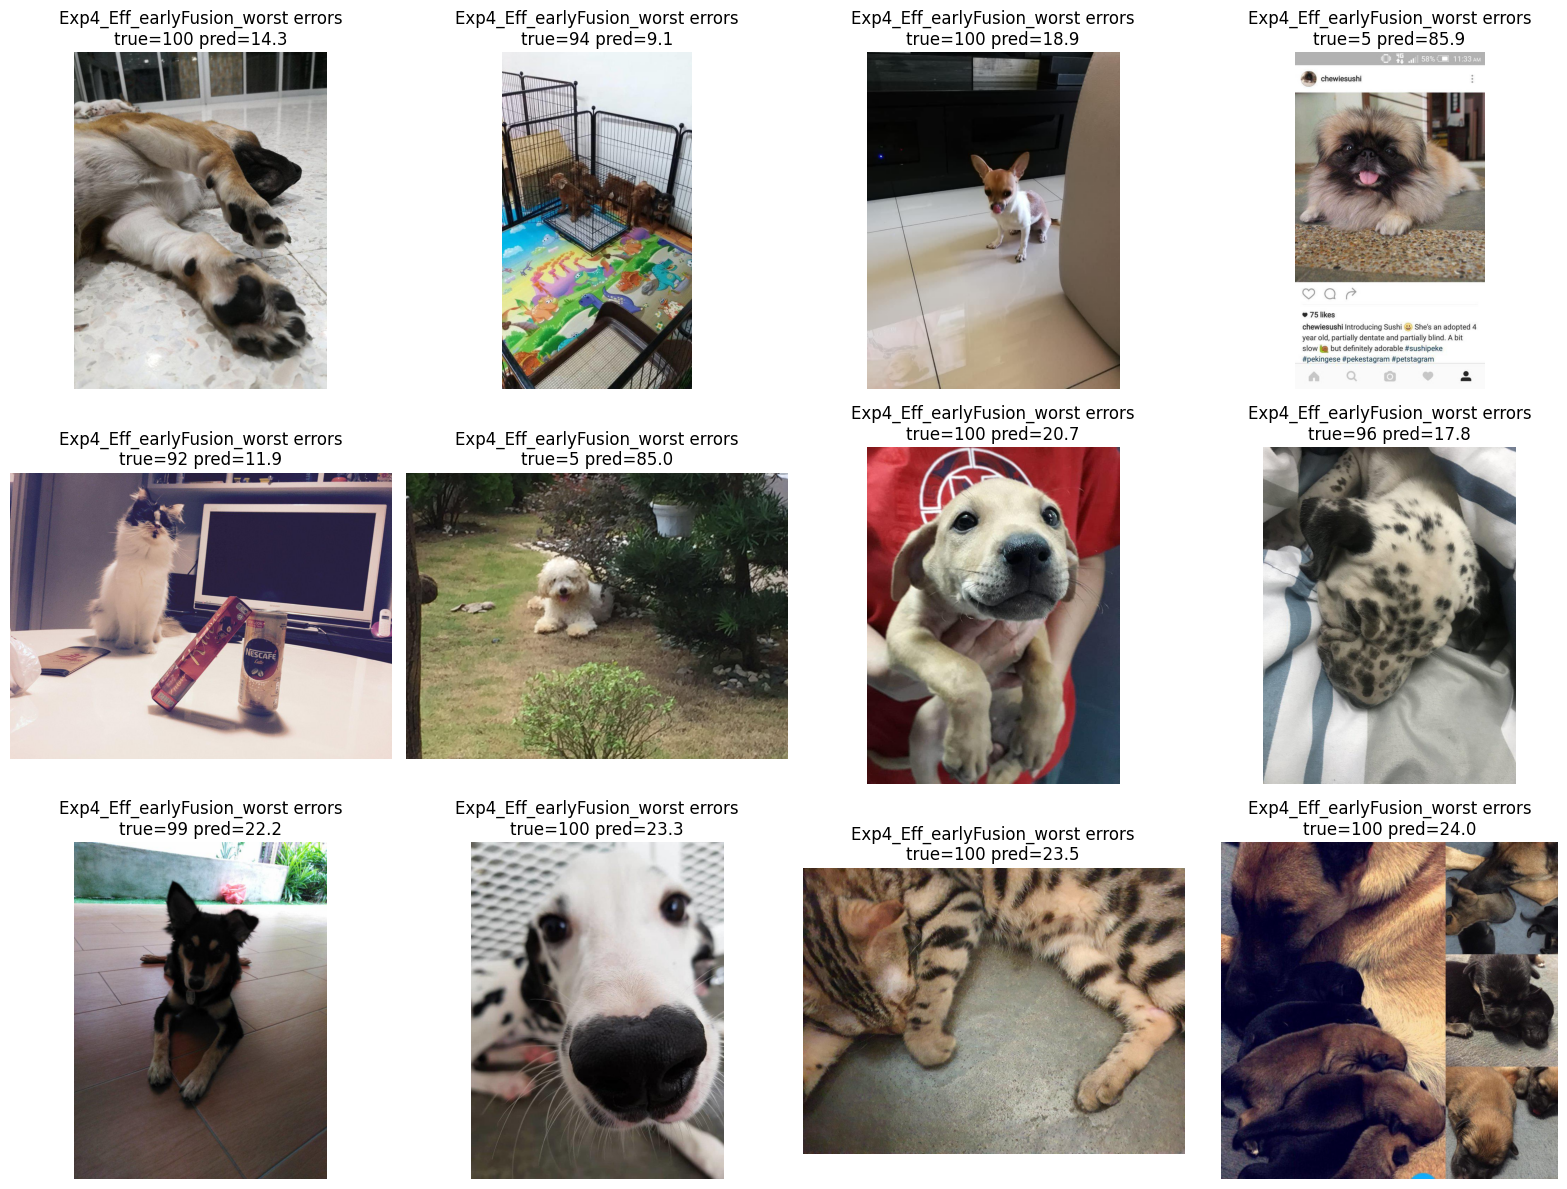

In [ ]:
# Images of worst errors
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="Exp4_Eff_earlyFusion_worst errors")

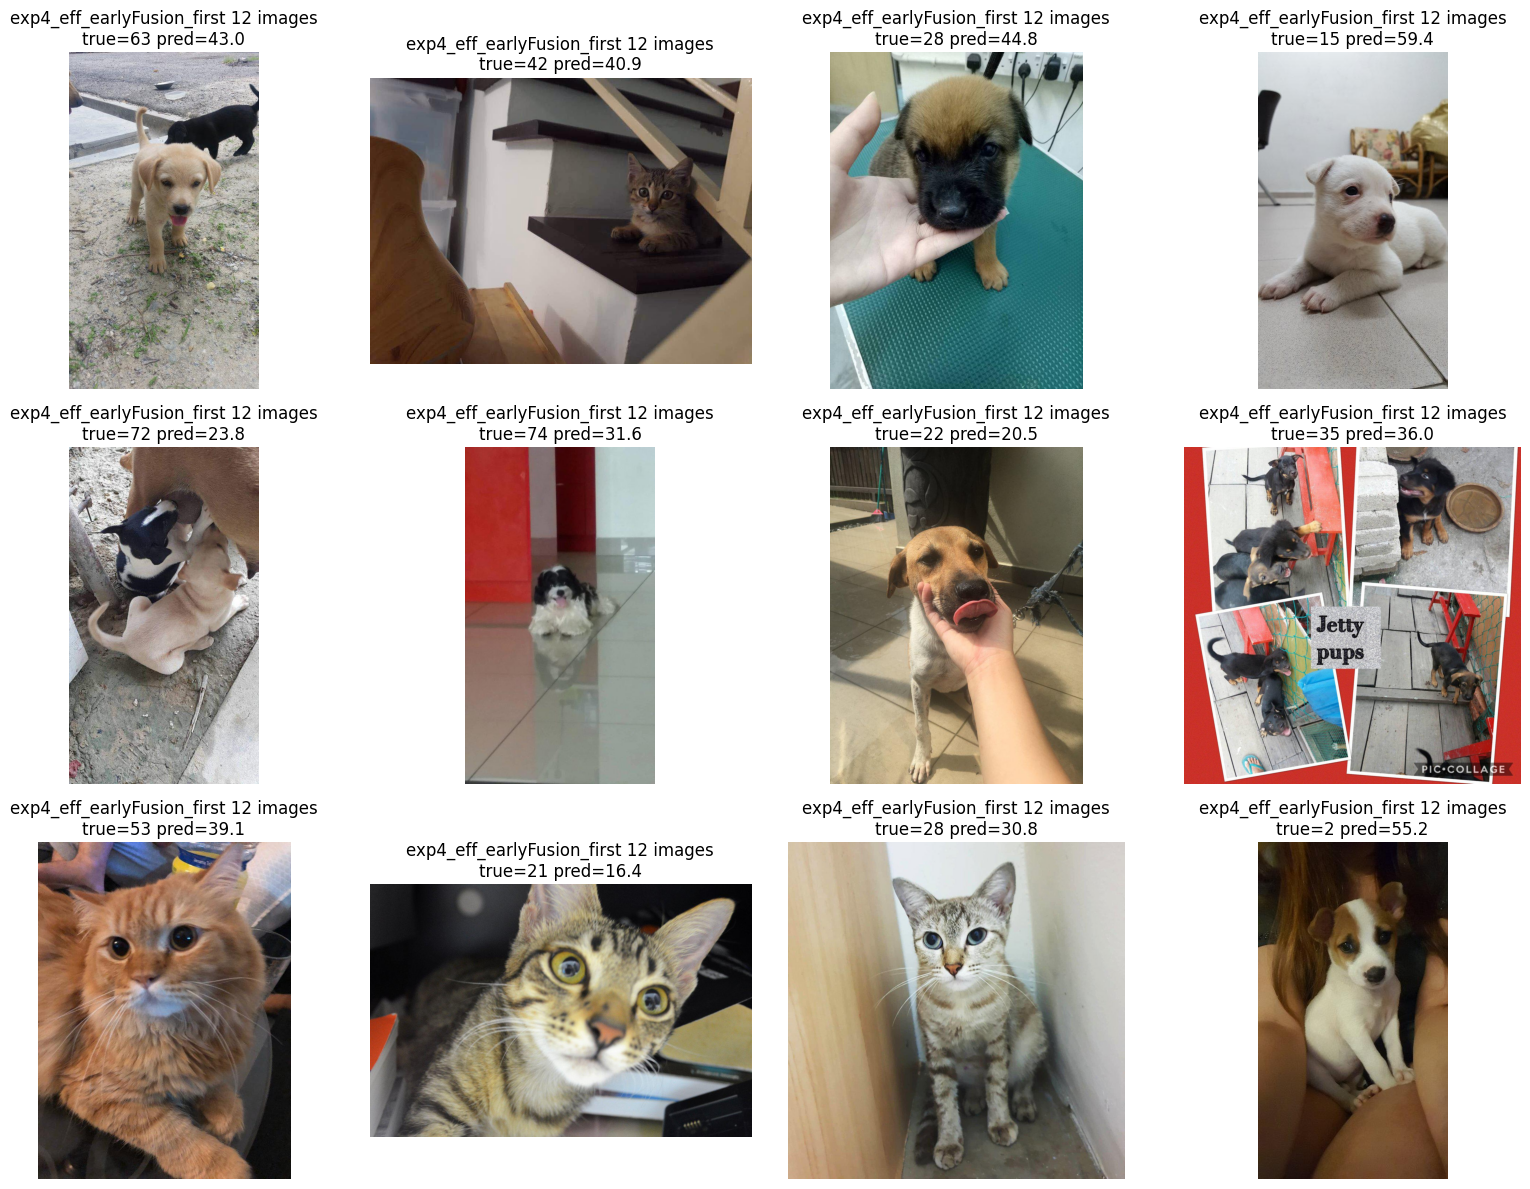

In [ ]:

show_images_grid(oof_df, img_folder, n=12, title_prefix="exp4_eff_earlyFusion_first 12 images")